<a href="https://colab.research.google.com/github/samuelamankwaa123/A-B_Data_Testing/blob/main/Tableau_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("tableau_sales_dataset_1500_rows.csv")

In [5]:
df

,Order_Date,Country,City,Category,Segment,Sales,Quantity,Profit
0,2024-11-10,Sweden,Stockholm,Clothing,Consumer,354.24,3,-51.37
1,2024-02-09,Netherlands,Amsterdam,Groceries,Home Office,1457.90,6,-290.96
2,2022-01-22,Spain,Madrid,Electronics,Corporate,63.78,9,-2.54
3,2022-07-09,Netherlands,Utrecht,Furniture,Home Office,226.68,3,2.35
4,2023-10-09,Spain,Madrid,Clothing,Consumer,382.52,7,-73.71
...,...,...,...,...,...,...,...,...
1495,2023-10-11,Spain,Madrid,Furniture,Consumer,1312.96,8,-156.58
1496,2023-07-02,France,Paris,Sports,Home Office,193.48,9,37.76
1497,2022-02-19,Poland,Warsaw,Sports,Corporate,1569.18,8,-194.50
1498,2024-12-19,France,Paris,Furniture,Corporate,942.26,3,247.92


In [6]:
df.describe()

,Sales,Quantity,Profit
count,1500.000000,1500.000000,1500.000000
mean,1023.718687,4.986000,63.262427
std,557.929836,2.608385,192.122176
min,52.410000,1.000000,-380.830000
25%,535.897500,3.000000,-55.277500
50%,1024.265000,5.000000,32.545000
75%,1512.262500,7.000000,176.660000
max,1998.150000,9.000000,689.570000


Linear Regression MAE: 481.37828114716024
Decision Tree MAE: 479.683287799727
Linear Regression R2: -0.009611741370683324
Decision Tree R2: -0.003796984203348508
       Actual  Linear_Pred    Tree_Pred
1116  1502.49  1012.564753  1006.375518
1368   196.43  1011.640665  1006.375518
422    401.60  1013.488841  1023.578583
413   1060.02  1013.026797  1023.578583
451   1467.76  1011.640665  1006.375518


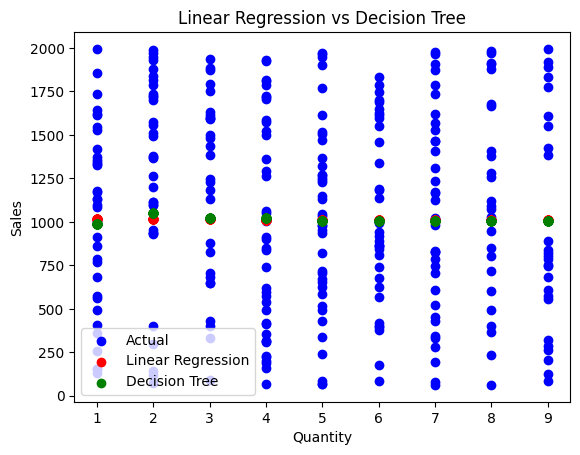

In [7]:
# ==========================
# IMPORTS
# ==========================

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ==========================
# SELECT FEATURES
# ==========================
x = df[["Quantity"]]   # independent variable
y = df["Sales"]        # target variable

# ==========================
# TRAIN TEST SPLIT
# ==========================
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# ==========================
# MODEL 1: LINEAR REGRESSION
# ==========================
lin_model = LinearRegression()
lin_model.fit(x_train, y_train)
lin_pred = lin_model.predict(x_test)

# ==========================
# MODEL 2: DECISION TREE
# ==========================
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(x_train, y_train)
tree_pred = tree_model.predict(x_test)

# ==========================
# EVALUATION
# ==========================
print("Linear Regression MAE:", mean_absolute_error(y_test, lin_pred))
print("Decision Tree MAE:", mean_absolute_error(y_test, tree_pred))

print("Linear Regression R2:", r2_score(y_test, lin_pred))
print("Decision Tree R2:", r2_score(y_test, tree_pred))

# ==========================
# COMPARISON TABLE
# ==========================
comparison = pd.DataFrame({
    "Actual": y_test,
    "Linear_Pred": lin_pred,
    "Tree_Pred": tree_pred
})
print(comparison.head())

# ==========================
# VISUALIZATION
# ==========================
plt.scatter(x_test, y_test, color="blue", label="Actual")
plt.scatter(x_test, lin_pred, color="red", label="Linear Regression")
plt.scatter(x_test, tree_pred, color="green", label="Decision Tree")

plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Linear Regression vs Decision Tree")
plt.legend()
plt.show()